PGD @ N=20… 2.08629e-02
PGD @ N=60… 7.61120e-03
PGD @ N=100… 4.68820e-03
PGD @ N=140… 3.38158e-03
PGD @ N=180… 2.71128e-03
PGD @ N=220… 2.22708e-03
PGD @ N=260… 1.89736e-03
PGD @ N=300… 1.65062e-03
PGD @ N=340… 1.45067e-03
PGD @ N=380… 1.31125e-03
PGD @ N=420… 1.20262e-03
PGD @ N=460… 1.10654e-03
PGD @ N=500… 1.01720e-03
PGD @ N=540… 9.47379e-04
PGD @ N=580… 8.95426e-04
PGD @ N=620… 8.29976e-04
PGD @ N=660… 7.60898e-04
PGD @ N=700… 7.39458e-04
PGD @ N=740… 6.91232e-04
PGD @ N=780… 6.51735e-04
PGD @ N=820… 6.02677e-04
PGD @ N=860… 5.72175e-04
PGD @ N=900… 5.51061e-04
PGD @ N=940… 5.57723e-04
PGD @ N=980… 5.26356e-04
PGD @ N=1020… 4.76973e-04


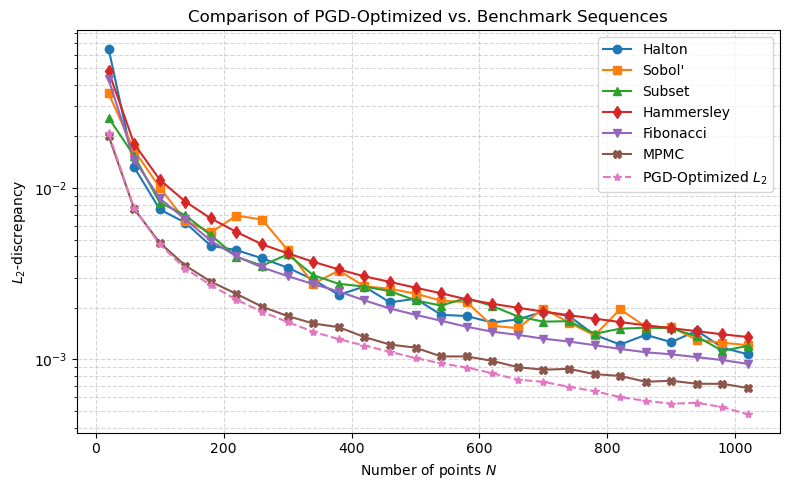

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# -----------------------------------------------------------------------------
# 1) The list of N values
# -----------------------------------------------------------------------------
N_list = np.array([
    20,  60, 100, 140, 180, 220, 260, 300, 340, 380, 420, 460, 500,
    540, 580, 620, 660, 700, 740, 780, 820, 860, 900, 940, 980, 1020
])

# -----------------------------------------------------------------------------
# 2) Benchmark L2-discrepancies from Table 4
# -----------------------------------------------------------------------------
halton      = np.array([
  0.06511,0.01323,0.00751,0.00627,0.00460,0.00434,0.00389,0.00343,
  0.00292,0.00238,0.00266,0.00215,0.00226,
  0.00182,0.00179,0.00164,0.00171,0.00190,0.00179,0.00139,0.00122,
  0.00139,0.00126,0.00147,0.00117,0.00107
])
sobol       = np.array([
  0.03564,0.01660,0.01006,0.00645,0.00551,0.00690,0.00655,0.00435,
  0.00276,0.00330,0.00267,0.00258,0.00242,
  0.00220,0.00216,0.00157,0.00152,0.00198,0.00164,0.00138,0.00196,
  0.00155,0.00154,0.00130,0.00125,0.00121
])
subset_sel  = np.array([
  0.02569,0.01541,0.00823,0.00693,0.00530,0.00397,0.00352,0.00410,
  0.00310,0.00276,0.00266,0.00250,0.00221,
  0.00206,0.00228,0.00205,0.00178,0.00166,0.00167,0.00141,0.00151,
  0.00153,0.00152,0.00136,0.00112,0.00120
])
hammersley  = np.array([
  0.04796,0.01812,0.01119,0.00833,0.00664,0.00554,0.00469,0.00416,
  0.00371,0.00335,0.00305,0.00283,0.00262,
  0.00243,0.00224,0.00211,0.00200,0.00190,0.00181,0.00173,0.00165,
  0.00158,0.00152,0.00146,0.00140,0.00135
])
fibonacci   = np.array([
  0.04324,0.01465,0.00870,0.00657,0.00492,0.00399,0.00344,0.00306,
  0.00275,0.00249,0.00221,0.00198,0.00182,
  0.00168,0.00155,0.00145,0.00139,0.00132,0.00127,0.00121,0.00115,
  0.00110,0.00107,0.00103,0.00099,0.00094
])
mpmc        = np.array([
  0.02016,0.00756,0.00479,0.00353,0.00284,0.00241,0.00203,0.00179,
  0.00162,0.00154,0.00135,0.00122,0.00117,
  0.00104,0.00104,0.00098,0.00090,0.00087,0.00088,0.00082,0.00080,
  0.00074,0.00075,0.00072,0.00072,0.00068
])

# -----------------------------------------------------------------------------
# 3) The PGD machinery (exactly as before)
# -----------------------------------------------------------------------------
def fibonacci_lattice(n):
    phi = (jnp.sqrt(5.) - 1.) / 2.
    i   = jnp.arange(n)
    return jnp.stack([ i/n, (i*phi) % 1. ], axis=1)

def softmax(a, b, tau=1e-8):
    return 0.5 * (a + b + jnp.sqrt((a - b)**2 + tau))

def L2_smoothed(P, tau=1e-8):
    n = P.shape[0]
    a = jnp.sum((1 - P[:,0]**2)*(1 - P[:,1]**2))/(2*n)
    xi, xj = jnp.meshgrid(P[:,0], P[:,0], indexing='ij')
    yi, yj = jnp.meshgrid(P[:,1], P[:,1], indexing='ij')
    b = jnp.sum((1 - softmax(xi,xj,tau))*(1 - softmax(yi,yj,tau)))/(n**2)
    return 1/9 - a + b

def optimize_pgd(n, num_iters=300, lr=5e-4):
    P = fibonacci_lattice(n)
    opt = optax.adam(lr)
    st  = opt.init(P)
    fvg = jax.jit(jax.value_and_grad(L2_smoothed))
    for _ in range(num_iters):
        loss, g = fvg(P)
        upds, st = opt.update(g, st)
        P = jnp.clip(optax.apply_updates(P, upds), 0.0, 1.0)
    return np.array(P)

def L2_discrepancy(P):
    N = P.shape[0]
    sum1 = np.prod(1 - P**2, axis=1).sum()
    pm   = np.maximum(P[:,None,:], P[None,:,:])     # (N,N,2)
    sum2 = np.prod(1 - pm, axis=2).sum()
    return np.sqrt(3.**-2 - (1/N)*2.**-1*sum1 + (1/N**2)*sum2)

# -----------------------------------------------------------------------------
# 4) Run the sweep, collect PGD‐L2
# -----------------------------------------------------------------------------
pgd_L2 = []
for n in N_list:
    print(f"PGD @ N={n}…", end=" ")
    Popt = optimize_pgd(int(n), num_iters=300, lr=5e-4)
    val  = L2_discrepancy(Popt)
    print(f"{val:.5e}")
    pgd_L2.append(val)
pgd_L2 = np.array(pgd_L2)

# -----------------------------------------------------------------------------
# 5) Final plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(N_list, halton,      marker='o', label='Halton')
plt.plot(N_list, sobol,       marker='s', label="Sobol'")
plt.plot(N_list, subset_sel,  marker='^', label='Subset')
plt.plot(N_list, hammersley,  marker='d', label='Hammersley')
plt.plot(N_list, fibonacci,   marker='v', label='Fibonacci')
plt.plot(N_list, mpmc,        marker='X', label='MPMC')

plt.plot(N_list, pgd_L2,      marker='*', linestyle='--', label='PGD-Optimized $L_2$')

plt.xscale('linear')
plt.yscale('log')
plt.xlabel(r'Number of points $N$')
plt.ylabel(r'$L_2$-discrepancy')
plt.title('Comparison of PGD-Optimized vs. Benchmark Sequences')
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
